# Import

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")


# - dirs 
from ciim.src.common import cell_types, datasets, v_datasets, palette_datasets, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation

from ciim.src.tf_activity.helper import adata_lambda, net_lambda, calculate_tf_activity, get_consensus_network
from ciim.src.tf_activity.helper import compute_trend

from ciim.src.tf_activity.plots import plot_tf_act_validation, wrapper_heatmap_tf_d_v

from ciim.src.utils.plots import dotplot
from ciim.src.tf_activity.helper import retreive_stats, add_minor_data


ImportError: cannot import name 'get_consensus_network' from 'ciim.src.tf_activity.helper' (/home/jnourisa/projs/ongoing/ciim/src/tf_activity/helper.py)

In [ ]:
# - tf list 
task_grn_inference_dir = '../../task_grn_inference'
tf_all = np.loadtxt(f'{task_grn_inference_dir}/resources/grn_benchmark/prior/tf_all.csv', dtype=str)
skeleton = pd.read_csv(f'{task_grn_inference_dir}/resources/grn_benchmark/prior//skeleton.csv')
consensus_nets_dict = get_consensus_network(cell_types, datasets)

In [2]:
def compile_data(cell_type, target_tfs, target_filter_criteria='in_degree_c'):
    stats_tf = stats_all_sig_consistent[(stats_all_sig_consistent['cell_type']==cell_type) & (stats_all_sig_consistent['tf'].isin(target_tfs))]
    stats_targets = stats_targets_all[stats_targets_all['cell_type']==cell_type]
    net = consensus_nets_dict[cell_type]
    print('Put the data together ...')
    data_all = obj.wrapper_retreive_stats(stats_tf, stats_targets, net, filter_criteria=target_filter_criteria,
                n_top_targets=20)
    return data_all

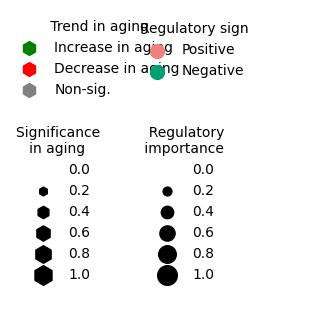

In [4]:
from ciim.src.tf_activity.plots import DotPlotTFtarget

obj = DotPlotTFtarget(tf_all, skeleton)
obj.plot_legend()

## Compare nets

In [5]:
from ciim.src.tf_activity.plots import compare_nets_plot

if False:
    compare_nets_plot(datasets+['data12'], cell_types, to_show='source')

# TF activity bulk


# Stats

In [11]:
stats_all = pd.read_csv('../output/tf_activation/stats_all_bulk_F.csv')
stats_discovery_consistent = stats_all[stats_all['analysis']=='discovery']
stats_validation = stats_all[stats_all['analysis']=='validation']
stats_validation_sig = stats_validation[stats_validation['meta_p_adj']<0.05]
stats_validation_consistent = stats_validation_sig[stats_validation_sig['trend']!='Inconsistent']

In [41]:
from ciim.src.tf_activity.plots import compare_stats_across_datasets
if False:
    compare_stats_across_datasets(stats_all.rename({'tf': 'gene'}, axis=1), y_label='TF count')
    plt.suptitle('TFs significantly associated with age', y=1.1)

## Number of sig TFs per cell type

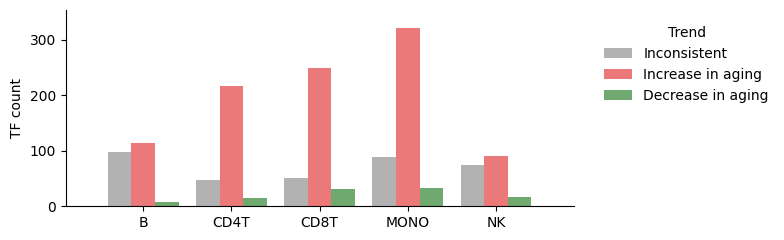

In [13]:
from ciim.src.common import cell_types, datasets, palette_datasets, surrogate_names, colors_blind, palette_trend 

df = stats_discovery_consistent[['tf', 'cell_type', 'meta_p_adj', 'trend']]
df['trend'] = df['trend'].astype(CategoricalDtype(categories=palette_trend.keys(), ordered=True))
df = df[~df.duplicated()].reset_index(drop=True)
df_counts = df.groupby(['cell_type', 'trend']).size().reset_index(name='Sig. TFs')

fig, ax = plt.subplots(1, 1, figsize=(8, 2.5))
sns.barplot(data=df_counts, x='cell_type', y='Sig. TFs', alpha=.6, hue='trend', palette=palette_trend, ax=ax)
ax.set_ylabel('TF count')
ax.set_xlabel('')
ax.margins(x=0.1, y=0.1)
ax.legend(loc=(1.05, 0.5), title='Trend', frameon=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# plt.suptitle('TFs significantly associated with age', fontsize=12)
plt.tight_layout()
plt.savefig(f'../output/tf_activation/trends.png', dpi=300)


## Shared sig TFs between cell types

['Tcm_Naive_CD8', 'Tcm_Naive_CD4', 'CD16_NK', 'Tem_Trm_CD8']


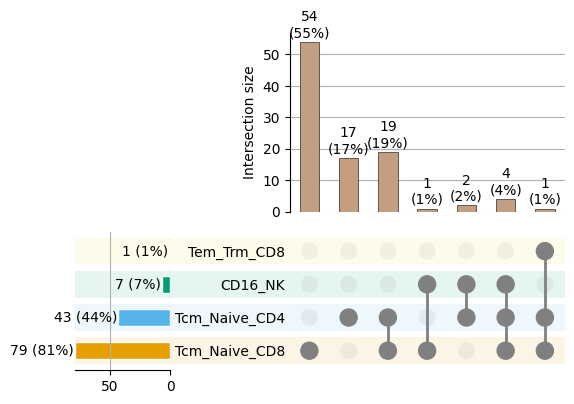

In [8]:
sys.path.append('../../')
from task_grn_inference.src.exp_analysis.helper import plot_interactions, create_interaction_df
df = stats_validation_consistent.copy()

df_dict = df.groupby(['cell_type'])['tf'].apply(list).to_dict()
interaction_main_df = create_interaction_df(df_dict)
aa = plot_interactions(interaction_main_df, min_subset_size=1)
plt.savefig(f'../output/tf_activation/interactions.png', dpi=300)
# plt.title('', pad=40)

Index(['SATB1', 'TCF7', 'PRDM1', 'ANXA1', 'PRNP', 'GATA3', 'BCL11B', 'ID2'], dtype='object')


Text(0.5, 1, 'Shared TFs')

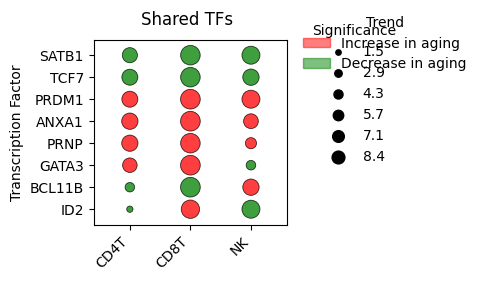

In [16]:
from ciim.src.utils.plots import dotplot
interaction3_df = interaction_main_df[interaction_main_df.sum(axis=1)==3]
degree3_tfs = interaction3_df.index
print(degree3_tfs)
selected_tfs = degree3_tfs
fig, ax = plt.subplots(1, 1, figsize=(2.5, len(selected_tfs)*.3), 
                        #  gridspec_kw={'width_ratios': [.2, .2]}, 
                         sharey=True)# - plot TF activation stats
mask = stats_validation_consistent['tf'].isin(selected_tfs).reindex(stats_validation_consistent.index, fill_value=False)
df = stats_validation_consistent[mask]
df['tf'] = pd.Categorical(df['tf'], categories=selected_tfs, ordered=True)
df = df.sort_values('tf')
df['cell_type'] = df['cell_type'].astype(CategoricalDtype(categories=['CD4T', 'CD8T', 'NK', 'MONO', 'B'], ordered=True))
dotplot(df, ax, color_col='trend', 
        size_col='neg_log10_adj_pval', 
        palette=palette_trend_2, 
        show_color_legend=True, 
        show_size_legend=True,
        size_legend_title='Significance',
        size_legend_loc=(1.1, 0.3),
        color_legend_loc=(1.05, 0.8))
ax.margins(x=0.3, y=0.1)
plt.savefig(f'../output/tf_activation/degree3_tfs.png', dpi=300)
plt.suptitle('Shared TFs', fontsize=12, y=1)

In [46]:
aaaa

NameError: name 'aaaa' is not defined

### Check what are those that are significant in T cells only

In [14]:
nk_tfs = interaction3_df[interaction3_df['NK']==True].index
mono_tfs = interaction3_df[interaction3_df['MONO']==True].index
nk_tfs = np.setdiff1d(nk_tfs, mono_tfs)
mono_tfs = np.setdiff1d(mono_tfs, nk_tfs)   
print(f'Shared in (NK, CD4T, CD8T): {nk_tfs}')
print(f'Shared in (MONO, CD4T, CD8T): {mono_tfs}')

Shared in (NK, CD4T, CD8T): ['ANXA1' 'BATF' 'BCL11B' 'GATA3' 'ID2' 'PRDM1' 'PRNP' 'RPS10' 'SATB1'
 'TCF7']
Shared in (MONO, CD4T, CD8T): ['BAX' 'CEBPB' 'HCLS1' 'KLF10' 'NUCB1' 'PSMA6']


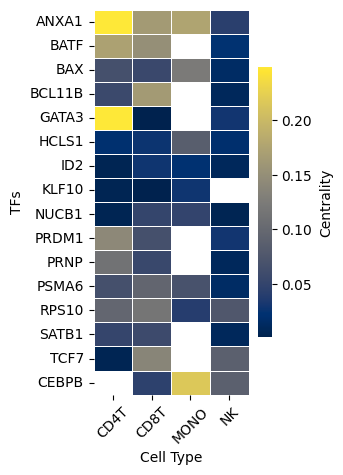

In [15]:
from src.utils.plots import heatplot_centrality

c_all = centrality_all[centrality_all['source'].isin(degree3_tfs)]
c_all = c_all[c_all['cell_type'].isin(['CD8T', 'CD4T', 'NK', 'MONO'])]
    
heatplot_centrality(c_all, cmap="cividis", figsize=(2.5, 5), quantile=.9, cbar_title='Centrality', y_label="TFs")  # Use 'log' or 'robust'

In [16]:
net_dicts = {}
for cell_type in ['CD8T', 'CD4T', 'NK', 'MONO']:
    data = compile_data(cell_type, degree3_tfs, target_filter_criteria='meta_p_adj_target')
    
    obj.plot_dotplot(data, 
                figsize=(6, 5), 
                height_ratios=(4, .3), 
                width_ratios=[0.2, 4], 
                ax_main_margin=(0.04, .1),
                title=f"Common TFs: {cell_type}")
    # - store the net
    net = data[['source', 'target', 'weight', 'trend','trend_target']].drop_duplicates()
    net_dicts[cell_type] = net

Put the data together ...


AttributeError: 'DotPlotTFtarget' object has no attribute 'wrapper_retreive_stats'

In [ ]:
from src.utils.plots import plot_net_nx
for cell_type in ['CD8T', 'CD4T', 'NK', 'MONO']:
    net = net_dicts[cell_type]
    plot_net_nx(net)
    plt.title(f"Common TFs: {cell_type}")

NameError: name 'net_dicts' is not defined

## Shared sig TFs between T types

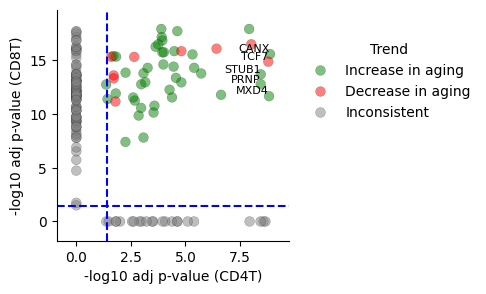

In [18]:
from ciim.src.tf_activity.plots import plot_joint_scatter

# Get significant TFs for CD4T and CD8T cells
stats_all_ts = stats_all_sig_consistent[stats_all_sig_consistent['cell_type'].isin(['CD4T', 'CD8T'])]
stats_all_ts = stats_all_ts[['tf', 'cell_type', 'neg_log10_adj_pval', 'trend']].drop_duplicates()
plot_joint_scatter(stats_all_ts, vars=['CD4T', 'CD8T'])

In [19]:
interaction_main_ts_df = interaction_main_df[['CD4T', 'CD8T']]
sig_tfs_ts = interaction_main_ts_df[interaction_main_ts_df.sum(axis=1)==2].index
sig_tfs_ts = np.setdiff1d(sig_tfs_ts, degree3_tfs)
print(sig_tfs_ts.shape)

(36,)


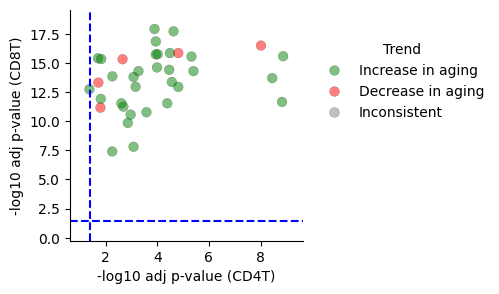

In [20]:
# Get significant TFs for CD4T and CD8T cells
stats_all_ts_sig = stats_all_ts[stats_all_ts['tf'].isin(sig_tfs_ts)]
plot_joint_scatter(stats_all_ts_sig, vars=['CD4T', 'CD8T'])

Text(0.5, 1.0, '')

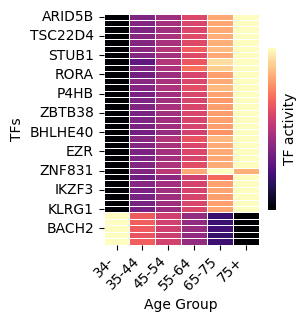

In [21]:
sig_tfs_ts_sorted = wrapper_heatmap_tf('CD8T', sig_tfs_ts)
plt.title('')

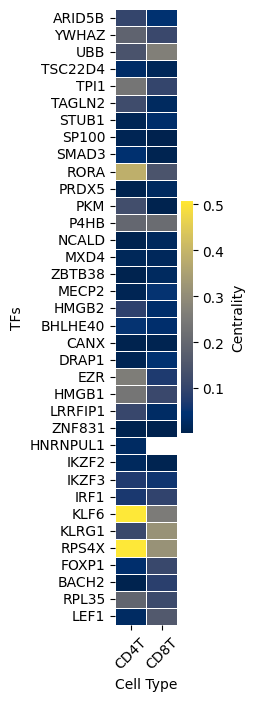

In [22]:
from src.utils.plots import heatplot_centrality

c_all = centrality_all[centrality_all['source'].isin(sig_tfs_ts_sorted)]
c_all = c_all[c_all['cell_type'].isin(['CD8T', 'CD4T'])].reset_index(drop=True)
c_all['tf'] = pd.Categorical(c_all['source'], categories=sig_tfs_ts_sorted, ordered=True)
c_all = c_all.sort_values('tf')[['source','cell_type', 'centrality']].drop_duplicates()
c_all

heatplot_centrality(c_all, cmap="cividis", figsize=(1, 8), quantile=.95, cbar_title='Centrality', y_label="TFs")  # Use 'log' or 'robust'

In [23]:
if False:
    net_dicts = {}
    for cell_type in ['CD8T', 'CD4T']:

        data = compile_data(cell_type, sig_tfs_ts_sorted, target_filter_criteria='meta_p_adj_target')
        obj.plot_dotplot(data, 
                        figsize=(6, 5), 
                        height_ratios=(4, .3), 
                        width_ratios=[0.2, 4], 
                        ax_main_margin=(0.04, .1),
                        title=f"Common TFs to T cells: {cell_type}")
        # - store the net
        net = data[['source', 'target', 'weight', 'trend','trend_target']].drop_duplicates()
        net_dicts[cell_type] = net

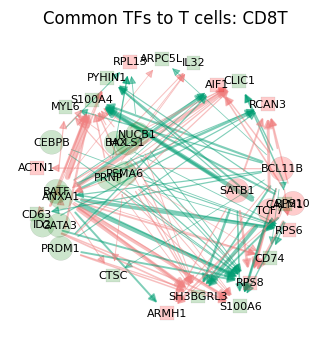

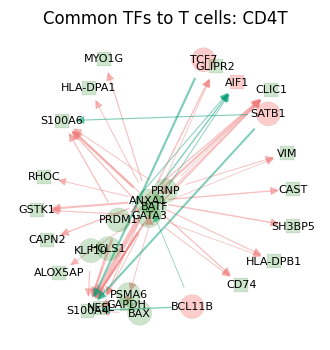

In [24]:
for cell_type in ['CD8T', 'CD4T']:
    net = net_dicts[cell_type]
    plot_net_nx(net)
    plt.title(f"Common TFs to T cells: {cell_type}")
    plt.show()

## Trajectory plot: TF acitvity with age

(981, 193)
(313, 290)
(981,) (981,) (981,)
(313,) (313,) (313,)


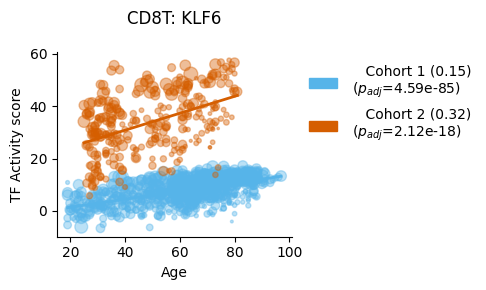

In [25]:
from ciim.src.tf_activity.plots import plot_trends
from ciim.src.common import palette_datasets
if True:
    # # - load data
    if True:
        cell_type = 'CD8T'
        adata_complete = {dataset: adata_lambda(dataset) for dataset in datasets}
        adata_dict = {dataset: adata[adata.obs['cell_type'] == cell_type] for dataset, adata in adata_complete.items()}
        nets_dict = {dataset: net_lambda(dataset, cell_type) for dataset in datasets}
        tf_acts_dict = {}
        for dataset in datasets:
            tf_acts = calculate_tf_activity(adata_dict[dataset], nets_dict[dataset])
            print(tf_acts.shape)
            tf_acts_dict[surrogate_names[dataset]] = tf_acts

    cell_type = 'CD8T'
    genes = ['KLF6']
    
    plot_trends(top_tfs=genes, datasets=[surrogate_names[d] for d in datasets], data_dict=tf_acts_dict, palette=palette_datasets, cell_type=cell_type, surrogate_names=surrogate_names)
    plt.tight_layout()
    plt.savefig(f'../output/tf_activation/trends_{cell_type}_case.png', dpi=300)

## TF activity trend vs expression trend in aging

In [26]:
# --------------- add the stats obtained from expression data (rather than TF activity)
from ciim.src.tf_activity.helper import determine_stats, adata_lambda

stats_store = []
for dataset in datasets:
    adata = adata_lambda(dataset)
    for cell_type in cell_types:
        print(f'dataset: {dataset}, cell_type: {cell_type}')
        stats_all_sig_df = stats_all_sig[stats_all_sig['cell_type'] == cell_type]
        adata_sub = adata[adata.obs['cell_type'] == cell_type]
        sig_tfs = stats_all_sig_df['tf'].unique()
    
        stats = determine_stats(adata_sub, sig_tfs)
        stats['dataset'] = dataset
        stats['cell_type'] = cell_type
        stats_store.append(stats)
expression_stats_all = pd.concat(stats_store).reset_index(drop=True)
expression_stats_all.head()

dataset: data1, cell_type: CD4T
dataset: data1, cell_type: CD8T
dataset: data1, cell_type: NK
dataset: data1, cell_type: B
dataset: data1, cell_type: MONO
dataset: data7_allTPs_jalil, cell_type: CD4T
dataset: data7_allTPs_jalil, cell_type: CD8T
dataset: data7_allTPs_jalil, cell_type: NK
dataset: data7_allTPs_jalil, cell_type: B
dataset: data7_allTPs_jalil, cell_type: MONO


,tf,p_value,slope,r2,intercept,spearman_corr,spearman_p,p_value_adj,dataset,cell_type
0,ANXA1,4.080359e-10,0.004494,3.914571e-02,4.655289,0.168898,1.028783e-07,3.375570e-09,data1,CD4T
1,ANXA11,1.573847e-01,0.000398,2.041017e-03,4.057285,0.059593,6.206985e-02,2.137613e-01,data1,CD4T
2,APEX1,9.938401e-01,-0.000002,6.091310e-08,3.700200,0.014182,6.573050e-01,9.938401e-01,data1,CD4T
3,ARID5B,4.443721e-34,0.005638,1.404821e-01,3.477421,0.378820,7.839327e-35,4.043786e-32,data1,CD4T
4,BACH2,1.060455e-01,-0.000919,2.666021e-03,2.333245,-0.036065,2.591066e-01,1.581990e-01,data1,CD4T


In [27]:
# - merge activation with expression sig stats
stats_all_sig_combined = stats_all_sig.merge(expression_stats_all[['tf', 'slope', 'p_value', 'dataset', 'cell_type']], on=['tf', 'cell_type' ,'dataset'], suffixes=('', '_expression'), how='left')
stats_all_sig_combined.head()

,tf,p_value,slope,r2,intercept,spearman_corr,spearman_p,p_value_adj,dataset,cell_type,meta_p,meta_p_adj,neg_log10_adj_pval,linear_trend,slope_expression,p_value_expression
0,ANXA1,8.083751e-05,0.027423,0.015755,52.659051,0.101929,1.389690e-03,1.257472e-04,data1,CD4T,8.083751e-05,2.326543e-04,3.633289,Increase in aging,0.004494,4.080359e-10
1,ANXA11,8.535220e-07,0.000979,0.024461,1.552793,0.129476,4.756596e-05,1.904962e-06,data1,CD4T,4.393259e-04,1.016480e-03,2.992901,Increase in aging,0.000398,1.573847e-01
2,APEX1,1.718643e-07,0.000222,0.027540,1.384808,0.171364,6.648315e-08,4.726269e-07,data1,CD4T,1.280647e-05,5.210908e-05,4.283087,Inconsistent,-0.000002,9.938401e-01
3,ARID5B,1.900678e-11,0.002540,0.045016,-3.587461,0.186587,3.899611e-09,1.272628e-10,data1,CD4T,6.844619e-06,3.230660e-05,4.490709,Increase in aging,0.005638,4.443721e-34
4,BACH2,2.506731e-13,-0.000251,0.053267,-0.369472,-0.194373,8.313074e-10,2.144648e-12,data1,CD4T,7.313195e-10,9.588411e-09,8.018253,Decrease in aging,-0.000919,1.060455e-01


In [28]:
stats_all_sig_combined['signed_-log10_pval'] = (-np.log10(stats_all_sig_combined['p_value'])) * np.sign(stats_all_sig_combined['slope'])
stats_all_sig_combined['signed_-log10_pval_exp'] = (-np.log10(stats_all_sig_combined['p_value_expression'])) * np.sign(stats_all_sig_combined['slope_expression'])

CD8T


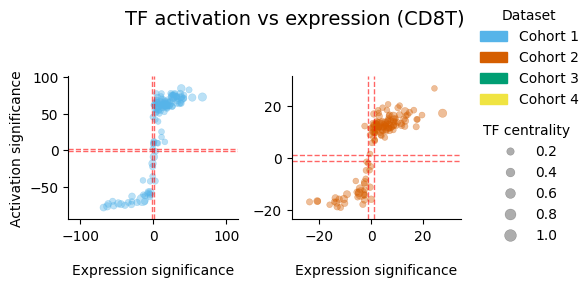

In [29]:
from src.tf_activity.plots import plot_activation_vs_expression
df = stats_all_sig_combined.copy()
df = df[df['cell_type']=='CD8T']
plot_activation_vs_expression(df, y_label='Activation significance', x_label='Expression significance')
plt.suptitle("TF activation vs expression (CD8T)", y=1.05, fontsize=14)
plt.tight_layout()
plt.savefig(f'../output/tf_activation/activation_vs_expression.png', dpi=300)

## In-degree centrality of target genes

In [30]:
from ciim.src.helper import determine_centrality
if False:
    top_target_n = 15
    top_targets_df = []
    for i, (cell_type, net_o) in enumerate(consensus_nets_dict.items()):
        # - determine in-degree centality
        sig_tfs = stats_all_sig_consistent[stats_all_sig_consistent['cell_type'] == cell_type]['tf'].unique()
        net = net_o[net_o['source'].isin(sig_tfs)]
        net['source_'] = net['source']
        net['source'] = net['target']
        net['target'] = net['source_']
        net.drop('source_', axis=1, inplace=True)

        c = determine_centrality(net, use_weight=False)
        c = c.sort_values('centrality', ascending=False)[:top_target_n]
        c['cell_type'] = cell_type
        top_targets_df.append(c)
    top_targets_df = pd.concat(top_targets_df)
    top_targets_df['is_tf'] = top_targets_df.index.isin(tf_all)
    top_targets_df['is_tf'] = top_targets_df['is_tf'].replace({True: 'TF', False: 'Non-TF'})
    top_targets_df['is_tf'] = top_targets_df['is_tf'].astype('category')
    top_targets_df = top_targets_df.reset_index().rename({'index': 'target'}, axis=1)
    top_targets_df.head()


    fig, ax = plt.subplots(1, 1, figsize=(3, 10), sharey=True)
    dotplot(top_targets_df, ax, color_col='is_tf', size_col='centrality', y='target', 
            color_legend_title='Gene role', size_legend_title='Centrality', palette={'TF':'blue', 'Non-TF':'red'},
            sizes=(20,200))
    plt.ylabel('Gene')

## Unique TFs

In [31]:
def get_unique_central_tfs(df, cell_type, n=20):
    df = df[df['cell_type']==cell_type]
    df = df[~df['tf'].isin(degree3_tfs)]
    net = consensus_nets_dict[cell_type]
    tfs = net.groupby(['source']).size().sort_values(ascending=False).head(n).index.to_numpy()
    return tfs
def get_unique_sig_tfs(df_all, cell_type, n=20):
    other_tfs = df_all[df_all['cell_type']!=cell_type]['tf'].unique()
    df = df_all[df_all['cell_type']==cell_type]
    this_cell_tfs = df['tf'].unique()
    unique_tfs = np.setdiff1d(this_cell_tfs, other_tfs)
    df = df[df['tf'].isin(unique_tfs)]
    tfs = df.sort_values('meta_p_adj', ascending=True).head(n)['tf'].to_numpy()
    return np.unique(tfs)

In [32]:
unique_tfs_dict = {}
tfs_sig_all = {}
for cell_type in ['MONO', 'CD8T', 'CD4T']:
    unique_tfs_dict[cell_type] = get_unique_sig_tfs(stats_all_sig_consistent, cell_type=cell_type)

    tfs = np.unique(np.concatenate([unique_tfs_dict[cell_type], degree3_tfs, sig_tfs_ts]))
    tfs_sig_all[cell_type] = tfs

In [33]:
if False:
    unique_data_dict = {}
    for cell_type in ['MONO', 'CD8T', 'CD4T']:
        
        tfs = unique_tfs_dict[cell_type]
        data = compile_data(cell_type, tfs, target_filter_criteria='meta_p_adj_target')
        unique_data_dict[cell_type] = data


In [34]:
if False:
    for cell_type, data in unique_data_dict.items():
        title=f"Unique TFs: {cell_type}"
        tfs = data['source'].unique()
        obj.plot_dotplot(data, 
                    figsize=(6, 4.5), 
                    height_ratios=(4, .3), 
                    width_ratios=[0.2, 4], 
                    ax_main_margin=(0.04, .1),
                    title=title)
        plt.suptitle(cell_type, y=1.05)

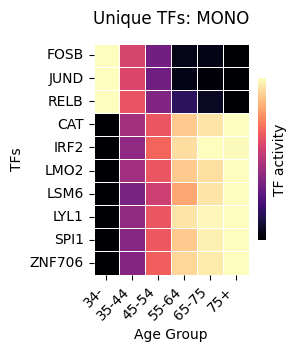

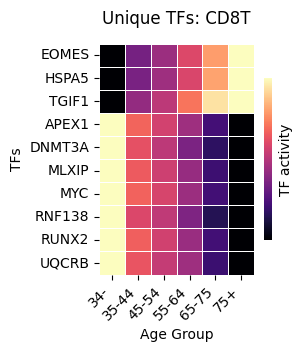

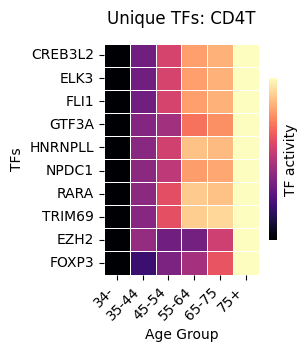

In [35]:
ordered_unique_tfs_dict = {}

for cell_type in ['CD8T']:
    tfs = unique_tfs_dict[cell_type]
    title=f"Unique TFs: {cell_type}"
    ordered_tfs = wrapper_heatmap_tf(cell_type, tfs)
    ordered_unique_tfs_dict[cell_type] = ordered_tfs
    plt.title(title, y=1.05)

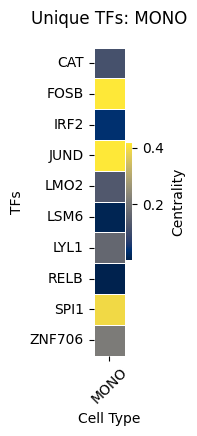

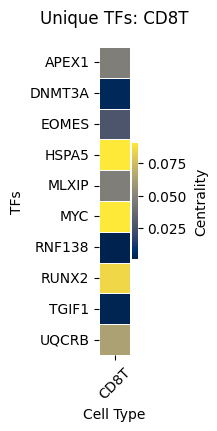

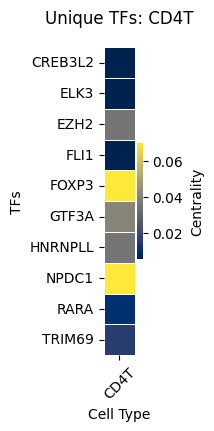

In [36]:
from src.utils.plots import heatplot_centrality
for cell_type, tfs in unique_tfs_dict.items():
    title = f"Unique TFs: {cell_type}"
    c_all = centrality_all[centrality_all['source'].isin(tfs)]
    c_all = c_all[c_all['cell_type'].isin([cell_type])]
    heatplot_centrality(c_all, cmap="cividis", figsize=(.5, 4), quantile=.8, cbar_title='Centrality', y_label="TFs")  # Use 'log' or 'robust'
    plt.title(title, y=1.05)


In [37]:
if False:
    for cell_type, data in unique_data_dict.items():
        net = data[['source', 'target', 'weight', 'trend','trend_target']].drop_duplicates()
        plot_net_nx(net)
        plt.title(f"Unique TFs: {cell_type}")
        plt.show()

## GSEA

In [38]:
from ciim.src.tf_activity.helper import pathway_analysis_wrapper
pathway_scores = pathway_analysis_wrapper(stats_all_sig_consistent)
pathway_scores["neg_log10_adj_pval"] = -np.log10(pathway_scores["Adjusted P-value"])

cell_type: CD4T, trend: Increase in aging, n tfs: 63
(9, 10)
cell_type: CD4T, trend: Decrease in aging, n tfs: 11
(3, 10)
cell_type: CD8T, trend: Increase in aging, n tfs: 106
(6, 10)
cell_type: CD8T, trend: Decrease in aging, n tfs: 31
(6, 10)
cell_type: NK, trend: Increase in aging, n tfs: 12
(2, 10)
cell_type: NK, trend: Decrease in aging, n tfs: 7
(1, 10)
cell_type: MONO, trend: Increase in aging, n tfs: 28
(6, 10)
cell_type: MONO, trend: Decrease in aging, n tfs: 10
(5, 10)


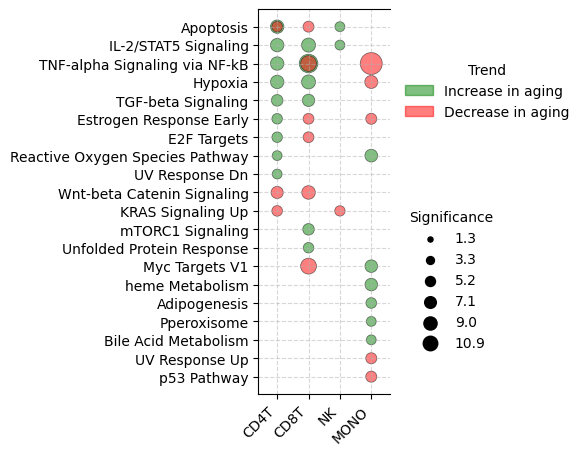

In [39]:
from ciim.src.utils.plots import dotplot

# Create figure
fig, ax = plt.subplots(figsize=(1.7, 5))
dotplot(pathway_scores, ax, color_col='trend', size_col='neg_log10_adj_pval', 
            x='cell_type', 
            y='Term', 
            palette=palette_trend_2, sizes=(50, 250),
            show_color_legend=True, 
            show_size_legend=True,
            size_legend_title='Significance',
            color_legend_title='Trend',
            size_legend_loc=(1.1, 0.1),
            color_legend_loc=(1.07, 0.7),
            y_label='',
            alpha=0.5)
ax.grid(True, linestyle="--", alpha=0.5)
ax.spines[['right']].set_visible(False)
ax.margins(x=.2, y=.05)
# plt.title("Canonical Hallmarks", pad=20)
plt.tight_layout()
plt.savefig(f'../output/tf_activation/pathways.png', dpi=300)

In [40]:
terms = pathway_scores.groupby(['cell_type'])['Term'].apply(list)
print('MONO:', terms['MONO'])
print('NK:',terms['NK'])
print('CD4T:',terms['CD4T'])
print('CD8T:',terms['CD8T'])

MONO: ['Reactive Oxygen Species Pathway', 'heme Metabolism', 'Myc Targets V1', 'Adipogenesis', 'Pperoxisome', 'Bile Acid Metabolism', 'TNF-alpha Signaling via NF-kB', 'Hypoxia', 'UV Response Up', 'p53 Pathway', 'Estrogen Response Early']
NK: ['Apoptosis', 'IL-2/STAT5 Signaling', 'KRAS Signaling Up']
CD4T: ['Apoptosis', 'IL-2/STAT5 Signaling', 'TNF-alpha Signaling via NF-kB', 'Hypoxia', 'TGF-beta Signaling', 'Estrogen Response Early', 'E2F Targets', 'Reactive Oxygen Species Pathway', 'UV Response Dn', 'Wnt-beta Catenin Signaling', 'Apoptosis', 'KRAS Signaling Up']
CD8T: ['TNF-alpha Signaling via NF-kB', 'IL-2/STAT5 Signaling', 'Hypoxia', 'TGF-beta Signaling', 'mTORC1 Signaling', 'Unfolded Protein Response', 'TNF-alpha Signaling via NF-kB', 'Myc Targets V1', 'Wnt-beta Catenin Signaling', 'Apoptosis', 'Estrogen Response Early', 'E2F Targets']


# TF activation single cell (std)

## Run to get std of TF activation using single cell data

In [41]:
from src.tf_activity.script import wrapper_tf_association_with_age

par = {
    # - global vars
    'cell_types': cell_types,
    'datasets': datasets, 
    'predictor_age_q': .8,
    'type': 'std',
    'stats_file': '../output/tf_activation/stats_std.csv',

}

if False:
    wrapper_tf_association_with_age(par)
    stats_std = pd.read_csv(par['stats_file'])
else:
    stats_std = pd.read_csv(par['stats_file'])
stats_std_sig = stats_std[stats_std['meta_p_adj'] < 0.05]
stats_std_consistent = stats_std_sig[stats_std_sig['trend']!='Inconsistent']
stats_std_consistent.sort_values('meta_p_adj').head()

,tf,p_value,slope,r2,intercept,spearman_corr,spearman_p,p_value_adj,dataset,cell_type,meta_p,meta_p_adj,neg_log10_adj_pval,linear_trend
668,HTATIP2,4.249731e-19,-0.012380,0.226503,2.391476,-0.486331,5.484684e-20,4.065576e-17,data7_allTPs_jalil,CD8T,8.000019e-13,2.960007e-11,10.528707,Decrease in aging
456,HTATIP2,8.000019e-13,-0.003147,0.051059,1.078373,-0.259320,1.539922e-16,7.640018e-12,data1,CD8T,8.000019e-13,2.960007e-11,10.528707,Decrease in aging
621,DNMT3A,2.889135e-16,-0.014101,0.193765,2.886083,-0.453117,2.979366e-17,1.637102e-15,data7_allTPs_jalil,CD8T,3.955461e-11,7.317603e-10,9.135631,Decrease in aging
426,DNMT3A,3.955461e-11,-0.002720,0.043615,1.003541,-0.249137,2.405256e-15,3.021972e-10,data1,CD8T,3.955461e-11,7.317603e-10,9.135631,Decrease in aging
438,FOSL2,5.895829e-11,-0.005399,0.042851,1.783495,-0.249222,2.351917e-15,3.883115e-10,data1,CD8T,5.895829e-11,8.725827e-10,9.059193,Decrease in aging


## Stats

Text(0.5, 1.1, 'Significant TFs (std)')

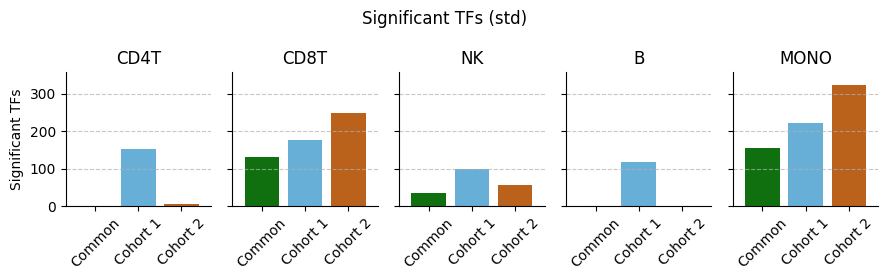

In [42]:
from ciim.src.tf_activity.plots import compare_stats_across_datasets

stats_std = pd.read_csv('../output/tf_activation/stats_std.csv')
compare_stats_across_datasets(stats_std.rename({'tf': 'gene'}, axis=1), y_label='Significant TFs')
plt.suptitle(f'Significant TFs (std)', y=1.1)

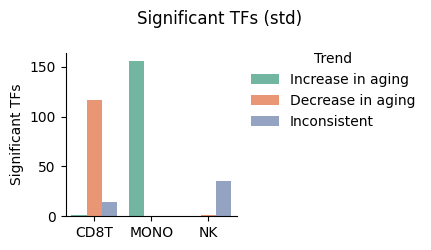

In [43]:
from src.tf_activity.helper import compute_trend
stats_std_sig = compute_trend(stats_std_sig, pval_col='meta_p_adj', slope_col='slope')
df = stats_std_sig[['tf', 'cell_type', 'meta_p_adj', 'trend', 'neg_log10_adj_pval']]
df = df[~df.duplicated()].reset_index(drop=True)
df_counts = df.groupby(['cell_type', 'trend']).size().reset_index(name='Sig. TFs')

fig, ax = plt.subplots(1, 1, figsize=(4.5, 2.5))
sns.barplot(data=df_counts, x='cell_type', y='Sig. TFs', hue='trend', palette='Set2', ax=ax)
ax.set_ylabel('Significant TFs')
ax.set_xlabel('')
ax.legend(loc=(1.05, 0.5), title='Trend', frameon=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.suptitle('Significant TFs (std)', fontsize=12)
plt.tight_layout()
plt.savefig(f'../output/tf_activation/trends_std.png', dpi=300)


## Interactions with TF bulk

main
std
CD8T
['main', 'std']
main
std
MONO
['std', 'main']


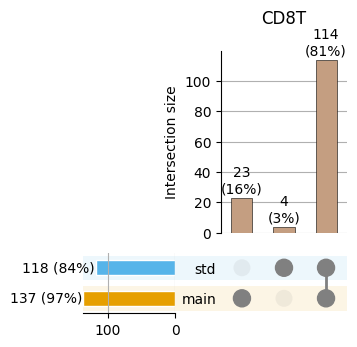

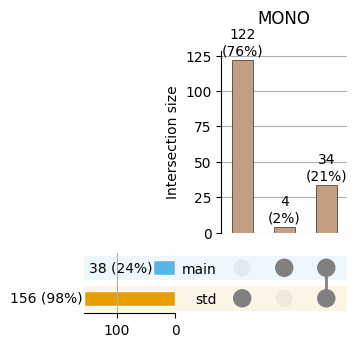

In [ ]:
unique_tfs_std_dict = {}
for cell_type in ['CD8T', 'MONO']:
    stats = retreive_stats(cell_type, types=['bulk', 'std'])
    df_dict = stats.groupby(['type'])['tf'].apply(list).to_dict()
    interaction_df = create_interaction_df(df_dict)
    if interaction_df.shape[0]==0:
        continue
    aa = plot_interactions(interaction_df, min_subset_size=1)
    plt.title(f'{cell_type}', pad=20)

    #- get unique tfs (std wrt activation)
    std_tfs = stats[stats['type']=='std']['tf'].unique()
    activation_tfs = stats[stats['type']=='bulk']['tf'].unique()
    unique_tfs_std = np.setdiff1d(std_tfs, activation_tfs)
    unique_tfs_std_dict[cell_type] = unique_tfs_std

## Interactions

['MONO', 'CD8T', 'NK']


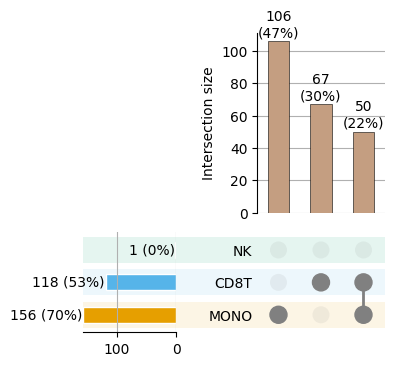

In [45]:
df = stats_std_consistent.copy()

df_dict = df.groupby(['cell_type'])['tf'].apply(list).to_dict()
interaction_df = create_interaction_df(df_dict)
aa = plot_interactions(interaction_df, min_subset_size=9)
plt.savefig(f'../output/tf_activation/interactions_std.png', dpi=300)
# plt.title('', pad=40)


Index(['NCOR1', 'P4HB', 'JUNB', 'KLF2', 'CSNK2B', 'LRRFIP1', 'HMGB2', 'YWHAZ',
       'ANXA1', 'NAP1L1', 'RBM8A', 'MAPK1', 'DRAP1', 'CANX', 'RBM42', 'KLF3',
       'SCAND1', 'PRDX5', 'CTNNB1', 'ID2', 'FOXP1', 'XBP1', 'TPI1', 'EWSR1',
       'FOSL2', 'KLF6', 'IRF1', 'REL', 'FOS', 'EEF1D', 'CEBPB', 'IRF9', 'RPL6',
       'BAX', 'RAB2A', 'HTATIP2', 'UBE2V1', 'EZR', 'ZEB2', 'ZBTB7A', 'UQCRB',
       'HCLS1', 'PSMA6', 'RAB7A', 'CEBPD', 'ATF6B', 'UBB', 'MLXIP', 'NUCB1',
       'HNRNPA1'],
      dtype='object')


Text(0.5, 0.9, 'Lineage specific shared TFs')

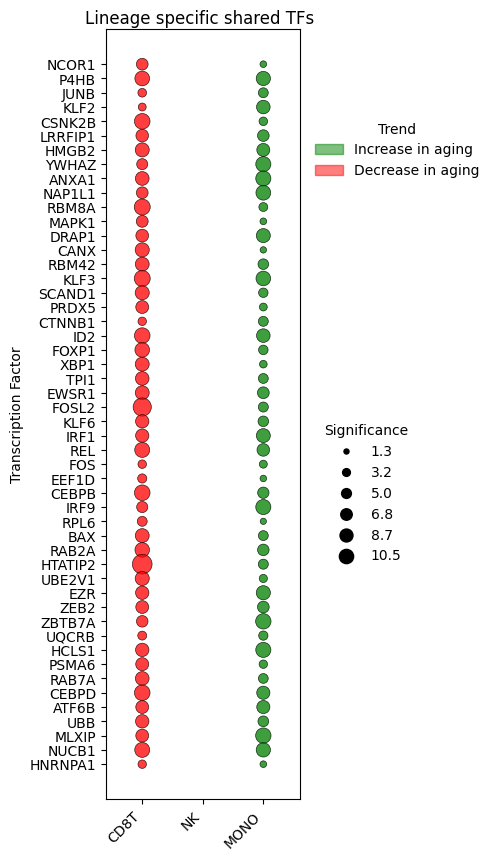

In [46]:
interaction_sub = interaction_df[['CD8T', 'MONO']]
interaction2_df = interaction_sub[interaction_sub.sum(axis=1)==2]
degree2_tfs_std = interaction2_df.index
print(degree2_tfs_std)
selected_tfs = degree2_tfs_std
fig, ax = plt.subplots(1, 1, figsize=(2.5, len(selected_tfs)*.2), 
                        #  gridspec_kw={'width_ratios': [.2, .2]}, 
                         sharey=True)# - plot TF activation stats
mask = stats_std_consistent['tf'].isin(selected_tfs).reindex(stats_std_consistent.index, fill_value=False)
df = stats_std_consistent[mask]
df['tf'] = pd.Categorical(df['tf'], categories=selected_tfs, ordered=True)
df = df.sort_values('tf')
df['cell_type'] = df['cell_type'].astype(CategoricalDtype(categories=['CD4T', 'CD8T', 'NK', 'MONO'], ordered=True))
dotplot(df, ax, color_col='trend', 
        size_col='neg_log10_adj_pval', 
        palette=palette_trend_2, 
        show_color_legend=True, 
        show_size_legend=True,
        size_legend_title='Significance',
        size_legend_loc=(1.1, 0.3),
        color_legend_loc=(1.05, 0.8))
ax.margins(x=0.3, y=0.05)
plt.savefig(f'../output/tf_activation/degree2_tfs_std.png', dpi=300)
plt.suptitle('Lineage specific shared TFs', fontsize=12, y=.9)

# Minor cell types

## Cell type proportions

In [2]:
obs_dict = {dataset:ad.read_h5ad(f'/vol/projects/jnourisa/datasets/{dataset}_sc.h5ad', backed='r').obs for dataset in datasets}

(981, 6)
(313, 6)
(981,) (981,) (981,)


KeyError: 'Cohort 1'

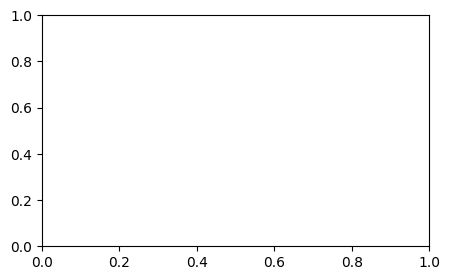

In [3]:
from ciim.src.common import mapping_major_2_minor
from ciim.src.tf_activity.plots import plot_trends

for cell_type in ['CD8T', 'CD4T']:
    subtypes = mapping_major_2_minor[cell_type]
    
    for i, subtype in enumerate(subtypes):
        df_dict = {}
        for dataset in datasets:
            obs = obs_dict[dataset]
            obs = obs[obs['cell_type']==cell_type]
            obs['age'] = pd.to_numeric(obs['age'], errors='coerce')
            obs[~np.isnan(obs['age'])]
            obs = obs.astype('str')
            obs = obs.sort_values('age')

            # Count single cells per (Sub_CT, donor_id, age)
            cell_counts = obs.groupby(['Sub_CT', 'donor_id', 'age']).size().reset_index(name='cell_count')
            total_counts = obs.groupby(['donor_id', 'age']).size().reset_index(name='total_cells')
            cell_counts = cell_counts.merge(total_counts, on=['donor_id', 'age'])
            cell_counts['fraction'] = cell_counts['cell_count'] / cell_counts['total_cells']

            # fig, ax = plt.subplots(1, 1, figsize=(5, 3))
            cell_counts_s = cell_counts[cell_counts['Sub_CT']==subtype]
            print(cell_counts_s.shape)
            cell_counts_a = ad.AnnData(X = cell_counts_s['fraction'].values.reshape(-1, 1), 
                                    obs=cell_counts_s, 
                                    var=cell_counts_s[['Sub_CT']].iloc[[0],:].set_index('Sub_CT'))
            cell_counts_a.obs['age'] = pd.to_numeric(cell_counts_a.obs['age'], errors='coerce')
            df_dict[surrogate_names[dataset]] = cell_counts_a
        plot_trends(top_tfs=[subtype], datasets=[surrogate_names[d] for d in datasets], data_dict=df_dict, palette=palette_datasets, cell_type=cell_type, surrogate_names=surrogate_names, y_label='Cell type frequency')

## TF activity

In [49]:
from ciim.src.tf_activity.script import wrapper_tf_association_with_age

par = {
    # - global vars
    'cell_types': cell_types,
    'datasets': datasets, 
    'predictor_age_q': .8,
    'type': 'minor',
    # 'meta_analysis_type': 'fisher', 
    'stats_file': '../output/tf_activation/stats_minor.csv',
}
if False:
    wrapper_tf_association_with_age(par)
else:
    stats_minor = pd.read_csv(par['stats_file'])
stats_minor_sig = stats_minor[stats_minor['meta_p_adj']<0.05]
stats_minor_sig = stats_minor_sig[stats_minor_sig['trend']!='Inconsistent']
stats_minor_sig.head()

,tf,p_value,slope,r2,intercept,spearman_corr,spearman_p,p_value_adj,dataset,cell_type,meta_p,meta_p_adj,neg_log10_adj_pval,linear_trend
1,ANXA1,1.071868e-03,0.019593,0.010875,35.785692,0.079290,1.298469e-02,1.650677e-03,data1,Tcm_Naive_CD4,1.071868e-03,2.624983e-03,2.580873,Increase in aging
2,ANXA11,1.996817e-05,0.000781,0.018420,1.162613,0.107025,7.865308e-04,4.270969e-05,data1,Tcm_Naive_CD4,1.363032e-03,3.207135e-03,2.493883,Increase in aging
4,ARID5B,2.191638e-09,0.001950,0.035921,-3.417198,0.162695,3.000125e-07,1.125041e-08,data1,Tcm_Naive_CD4,2.540796e-06,1.604713e-05,4.794603,Increase in aging
6,BACH2,1.058597e-09,-0.000202,0.037317,-0.302307,-0.155155,1.044819e-06,6.270152e-09,data1,Tcm_Naive_CD4,7.780894e-08,9.337073e-07,6.029789,Decrease in aging
7,BATF,3.064692e-05,0.002130,0.017602,-5.232565,0.107546,7.410049e-04,6.271360e-05,data1,Tcm_Naive_CD4,3.064692e-05,1.414473e-04,3.849405,Increase in aging


In [50]:
from ciim.src.tf_activity.plots import compare_stats_across_datasets
if False:
    stats_minor_cd8t = stats_minor[stats_minor['cell_type'].isin(['MAIT', 'Tcm_Naive_CD8', 'Tem_Temra_CD8', 'Tem_Trm_CD8'])]
    compare_stats_across_datasets(stats_minor_cd8t.rename({'tf': 'gene'}, axis=1), y_label='Significant TFs')
    plt.suptitle('Significant TFs (minor)', y=1.1)

## Low-dimensional plot

In [51]:
if False:
    adata = ad.read_h5ad('/vol/projects/jnourisa/datasets/data1_bulk_minor.h5ad')
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    sc.pp.pca(adata, use_highly_variable=True)  
    sc.pp.neighbors(adata, n_neighbors=15)  
    sc.tl.umap(adata)  
    adata.write('../output/tf_activation/umap/data_bulk_minor.h5ad')
    
else:
    adata = ad.read_h5ad('../output/tf_activation/umap/data_bulk_minor.h5ad')

In [52]:
# - merge stats to adata
sig_tf_size = stats_minor_sig[['cell_type', 'tf']].groupby('cell_type').size().reset_index(name='sig_tfs').rename({'cell_type': 'Sub_CT'}, axis=1)
sig_tf_size

,Sub_CT,sig_tfs
0,CD16_NK,32
1,MAIT,4
2,Tcm_Naive_CD4,130
3,Tcm_Naive_CD8,252
4,Tem_Effector_CD4,84
5,Tem_Trm_CD8,4
6,Treg,2


In [53]:
if 'sig_tfs' not in adata.obs.columns:
    adata.obs = adata.obs.merge(sig_tf_size, on='Sub_CT', how='left')
    # adata = adata[~adata.obs['sig_tfs'].isna(), :]
    adata.obs['sig_tfs'] = adata.obs['sig_tfs'].fillna(0)
    adata.obs.reset_index(drop=True, inplace=True)
    adata.obs['sig_tfs'] = adata.obs['sig_tfs'].astype(int)
    adata.obs['Sub_CT'] = adata.obs['Sub_CT'].str.replace('_',' ')

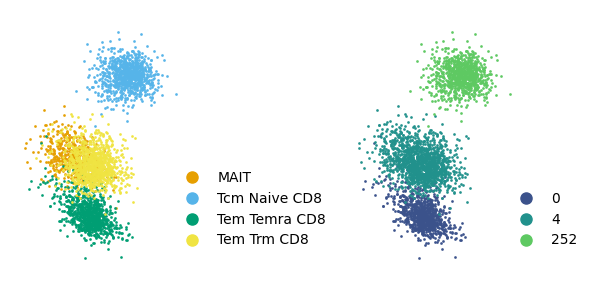

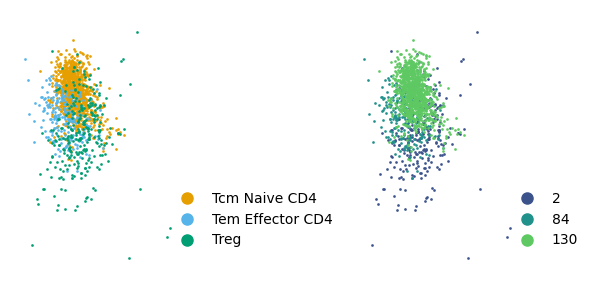

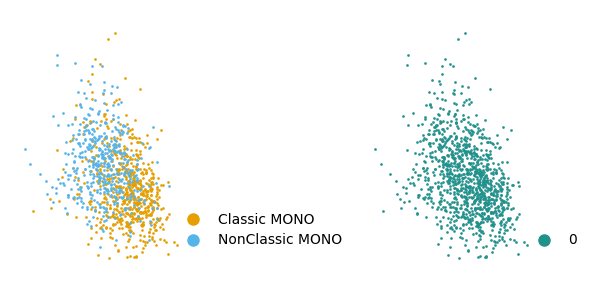

In [54]:
# - plot the umap of #sig tfs per subtype
from ciim.src.utils.util import plot_umap

for cell_type in ['CD8T', 'CD4T', 'NK', 'MONO']:
    adata_cell = adata[adata.obs['Major_CT'].isin([cell_type])]
    subtypes = adata_cell.obs['Sub_CT'].unique()
    groups = adata_cell.obs['sig_tfs'].unique()
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    ax = axes[0]
    plot_umap(adata_cell, color='Sub_CT', ax=ax, s=1, X_label='X_pca', alpha=.9, 
            bbox_to_anchor=(.9,.1), 
            margins=dict(x=.1, y=.1), palette={name: value for name, value in zip(sorted(subtypes), colors_blind)}
            )  
    ax = axes[1]
    plot_umap(adata_cell, color='sig_tfs', ax=ax, s=1, X_label='X_pca', alpha=.9, 
            bbox_to_anchor=(.9,.1), 
            margins=dict(x=.1, y=.1), 
            palette={name: value for name, value in zip(sorted(groups), sns.color_palette("viridis", n_colors=len(groups)))}
            )  
    plt.tight_layout()


## Major cell type sig TFs

main
CD8T
main
CD4T


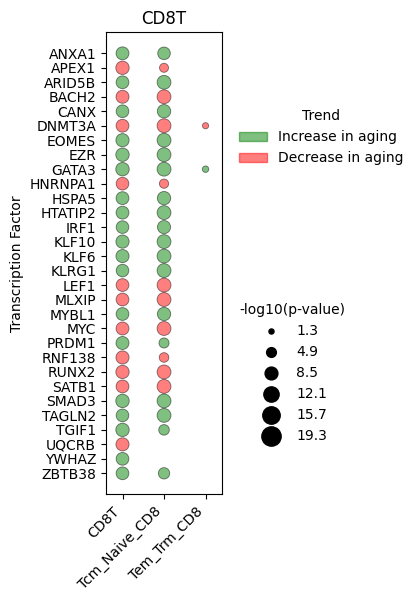

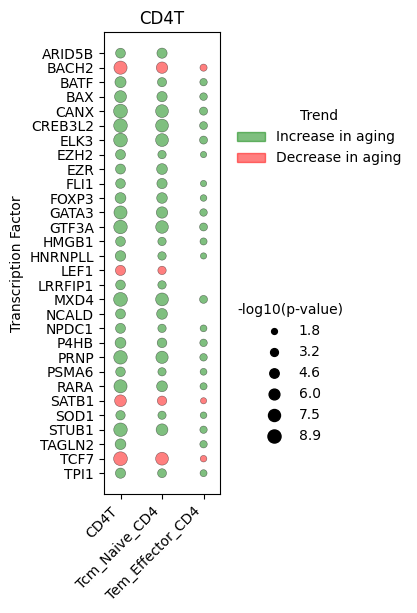

In [ ]:
for cell_type in ['CD8T', 'CD4T']:
    stats_main = retreive_stats(cell_type, types=['bulk'])
    tfs = stats_main.sort_values('meta_p_adj').head(30)['tf'].to_numpy()
    stats_main = add_minor_data(stats_main, cell_type)
    # - plot
    df_c = stats_main[stats_main['cell_type']==cell_type]
    df_c = add_minor_data(df_c, cell_type)
    fig, ax = plt.subplots(1, 1, figsize=(1.5, 6))
    
    df_c_s = df_c[df_c['tf'].isin(tfs)]
    df_c_s.type = df_c_s.type.apply(lambda name: {'bulk':f'{cell_type}'}.get(name,name))
    dotplot(df_c_s, ax, x='type', y='tf', color_col='trend', size_col='-log10_pval', 
            palette={key:palette_trend[key] for key in ['Increase in aging', 'Decrease in aging']}, sizes=(20, 100))
    # plt.suptitle(cell_type, y=1.01, fontsize=14)
    
    ax.margins(x=0.2, y=0.05)
    plt.title(cell_type)
    plt.tight_layout()
    plt.savefig(f'../output/tf_activation/dotplot_{cell_type}_{type}.png', dpi=300)

In [ ]:
aaa

# Gender specific

In [56]:
from src.tf_activity.script import wrapper_tf_association_with_age

par = {
    # - global vars
    'cell_types': cell_types,
    'datasets': datasets, 
    'predictor_age_q': .8,
}
if False:
    for gender in ['F', 'M']:
        par['type'] = gender
        par['stats_file'] = f'../output/tf_activation/stats_{gender}.csv'

        wrapper_tf_association_with_age(par)

In [57]:
from ciim.src.tf_activity.plots import compare_stats_across_datasets
if False:
    for gender in ['F', 'M']:
        stats_gender = pd.read_csv(f'../output/tf_activation/stats_{gender}.csv')
        compare_stats_across_datasets(stats_gender.rename({'tf': 'gene'}, axis=1), y_label='Significant TFs')
        plt.suptitle(f'Significant TFs ({gender})', y=1.1)

main
F
M
CD8T
main
F
M
CD4T


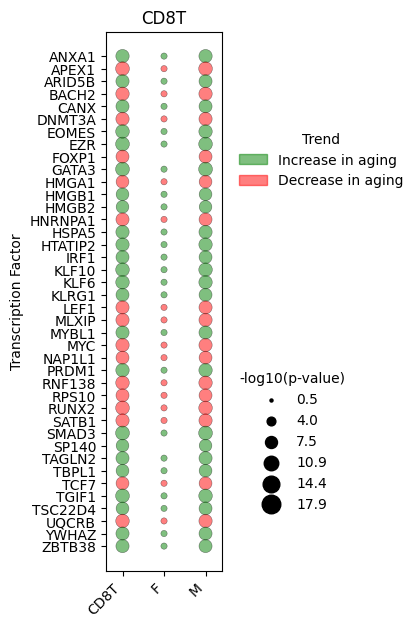

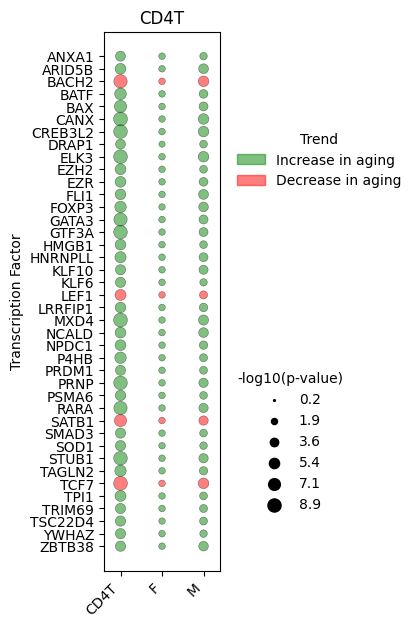

In [58]:
from ciim.src.tf_activity.helper import combine_data


for cell_type in ['CD8T', 'CD4T']:
    # tfs = tfs_sig_all[cell_type]

    df_c = retreive_stats(cell_type, types=['bulk', 'F', 'M'], keep_sig=False)
    df_main = df_c[df_c['type']=='bulk']
    tfs = df_main.sort_values('meta_p_adj').head(40)['tf'].to_numpy()
    # df_c['neg_log10_adj_pval'] = -np.log10(df_c['meta_p_adj'])

    # plot_joint_scatter(df_c, vars=['bulk', 'M'], col='type', annotate=False)
    # plt.title(cell_type + ' - main vs M')
    # plot_joint_scatter(df_c, vars=['bulk', 'F'], col='type', annotate=False)
    # plt.title(cell_type + ' - main vs F')

    fig, ax = plt.subplots(1, 1, figsize=(1.5, 7))
    
    df_c_s = df_c[df_c['tf'].isin(tfs)]
    df_c_s.type = df_c_s.type.apply(lambda name: {'bulk':f'{cell_type}'}.get(name,name))
    dotplot(df_c_s, ax, x='type', y='tf', color_col='trend', size_col='-log10_pval', 
            palette={key:palette_trend[key] for key in ['Increase in aging', 'Decrease in aging']}, sizes=(20, 100))
    # plt.suptitle(cell_type, y=1.01, fontsize=14)
    ax.margins(x=0.2, y=0.05)
    plt.title(cell_type)
    plt.tight_layout()

## Check if the incosistent sig TFs are associated with gender

main
F
M
CD8T
main
F
M
CD4T


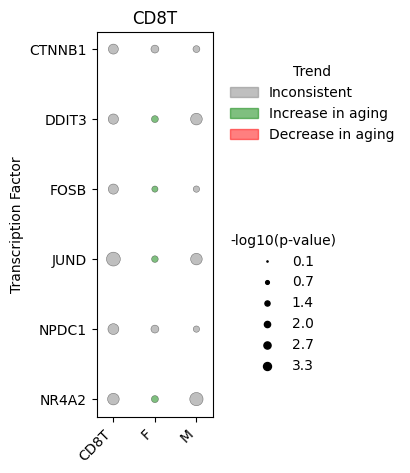

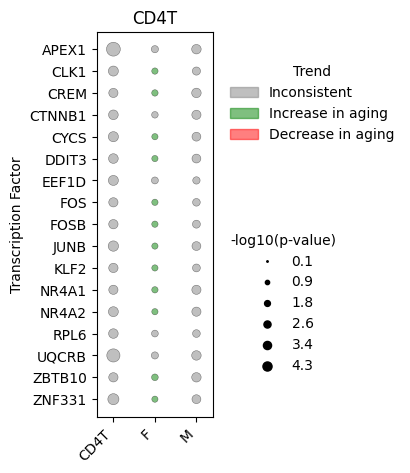

In [59]:
for cell_type in ['CD8T', 'CD4T']:
    tfs = stats_all_sig_inconsistent[stats_all_sig_inconsistent['cell_type']==cell_type]['tf'].unique()

    df_c = retreive_stats(cell_type, types=['bulk', 'F', 'M'], keep_sig=False, keep_inconsistent=False)

    fig, ax = plt.subplots(1, 1, figsize=(1.5, 5))
    
    df_c_s = df_c[df_c['tf'].isin(tfs)]
    df_c_s.type = df_c_s.type.apply(lambda name: {'bulk':f'{cell_type}'}.get(name,name))
    dotplot(df_c_s, ax, x='type', y='tf', color_col='trend', size_col='-log10_pval', 
            palette=palette_trend, sizes=(20, 100))
    # plt.suptitle(cell_type, y=1.01, fontsize=14)
    ax.margins(x=0.2, y=0.05)
    plt.title(cell_type)
    plt.tight_layout()

# Validation

## TFs shared between 3 cell types

In [60]:
from ciim.src.tf_activity.script import wrapper_validation_stats
dataset='data13'
cell_types = ['CD4T', 'CD8T', 'NK', 'MONO']
stats_all = wrapper_validation_stats(cell_types=cell_types, tfs=degree3_tfs, dataset=dataset)
stats_all['cell_type'] = stats_all['cell_type'].astype(CategoricalDtype(categories=cell_types, ordered=True))

stats_sig = stats_all[stats_all['adj_p_value']<0.05]

Loading data...


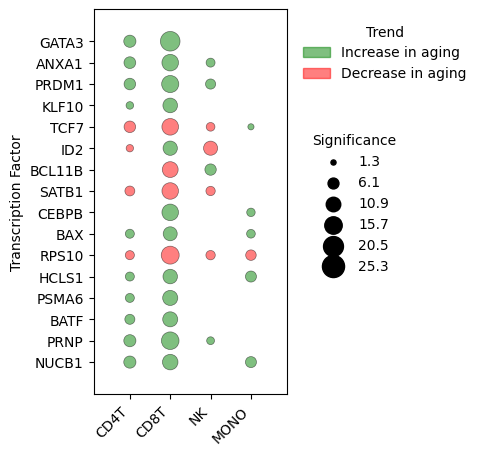

In [61]:
stats_all = stats_all[stats_all['adj_p_value'] < 0.05]
stats_all['neg_log10_adj_pval'] = -np.log10(stats_all['adj_p_value'])
stats_all['tf'] = stats_all['tf'].astype(CategoricalDtype(categories=degree3_tfs, ordered=True))
stats_all.sort_values('tf', inplace=True)

fig, ax = plt.subplots(1, 1, figsize=(2.5, 5))
dotplot(stats_all, ax, color_col='trend', 
        size_col='neg_log10_adj_pval', 
        palette=palette_trend_2, 
        show_color_legend=True, 
        show_size_legend=True,
        size_legend_title='Significance',
        size_legend_loc=(1.1, 0.3),
        color_legend_loc=(1.05, 0.8))
ax.margins(x=0.3, y=0.1)

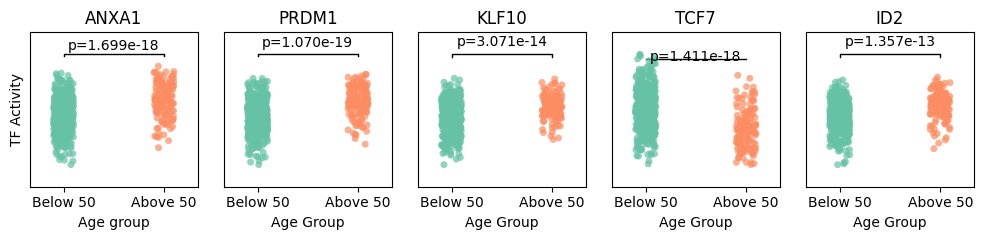

In [62]:

from ciim.src.tf_activity.plots import plot_tf_act_validation
cell_type = 'CD8T'
stats_df = stats_all[stats_all['cell_type']==cell_type]
tfs = stats_df['tf'].unique()[1:6]

stats_sig = stats_df[stats_df['adj_p_value']<0.05]
stats_sig = stats_sig[stats_sig['cell_type']==cell_type]
stats_sig = stats_sig[stats_sig['tf'].isin(tfs)]
plot_tf_act_validation(stats_sig)   

## TFs shared between Ts

In [63]:
cell_types = ['CD8T', 'CD4T']
stats_all = wrapper_validation_stats(cell_types=cell_types, tfs=sig_tfs_ts_sorted, dataset=dataset)
stats_all['tf'] = stats_all['tf'].astype(CategoricalDtype(categories=sig_tfs_ts_sorted, ordered=True)) 
stats_all.sort_values('tf', inplace=True)
stats_all['cell_type'] = stats_all['cell_type'].astype(CategoricalDtype(categories=cell_types, ordered=True))

stats_sig = stats_all[stats_all['adj_p_value']<0.05]

Loading data...


These TFs are not present in the validation set: []
These TFs are not present in the validation set: []
These TFs are not present in the validation set: ['MECP2']
These TFs are not present in the validation set: []


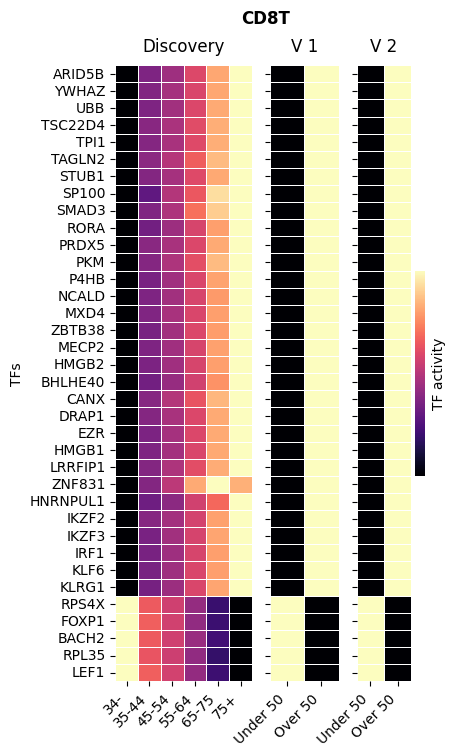

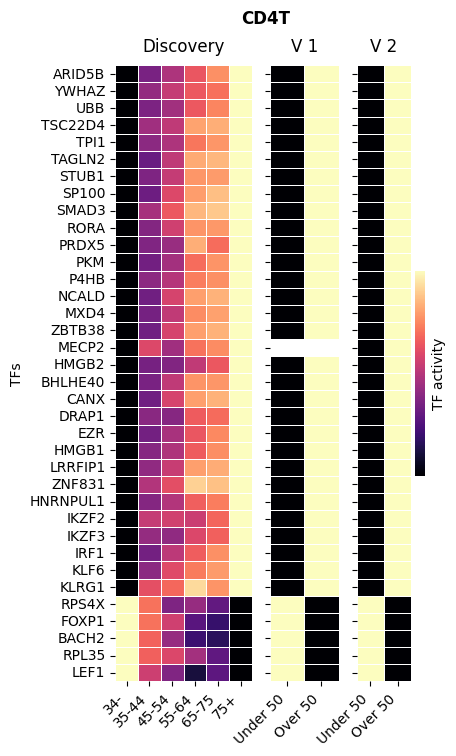

In [64]:
from ciim.src.tf_activity.plots import wrapper_heatmap_tf_d_v
for cell_type in ['CD8T', 'CD4T']:
    wrapper_heatmap_tf_d_v(cell_type=cell_type, tfs=sig_tfs_ts_sorted, cut_off=50, figsize=(4, 8), cmap="magma")
    plt.suptitle(cell_type, y=.95, fontsize=12, weight='bold')

CD8T


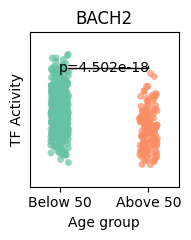

CD4T


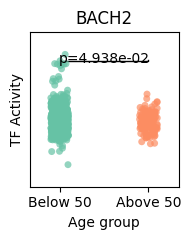

In [65]:
tfs = ['BACH2']
for cell_type in ['CD8T', 'CD4T']:
    print(cell_type)
    stats_sig_t = stats_all[stats_all['cell_type']==cell_type]
    stats_sig_t = stats_sig_t[stats_sig_t['tf'].isin(tfs)]
    plot_tf_act_validation(stats_sig_t)   


## Unique TFs for cell types

In [66]:
unique_tfs_dict['MONO']

array(['CAT', 'FOSB', 'IRF2', 'JUND', 'LMO2', 'LSM6', 'LYL1', 'RELB',
       'SPI1', 'ZNF706'], dtype=object)

These TFs are not present in the validation set: []
These TFs are not present in the validation set: []
These TFs are not present in the validation set: []
These TFs are not present in the validation set: []
These TFs are not present in the validation set: []
These TFs are not present in the validation set: []


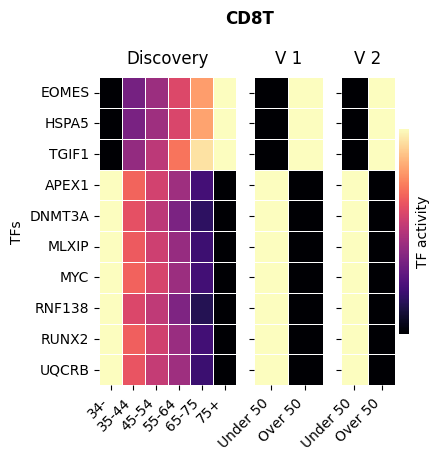

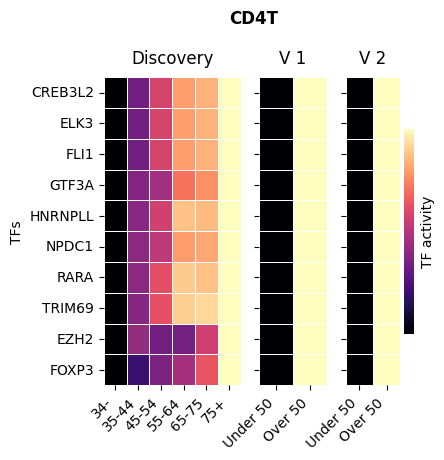

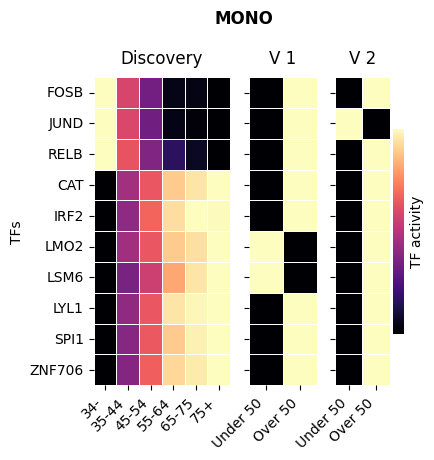

In [67]:
from ciim.src.tf_activity.plots import heatmap_tf_validation, process_trends_validation
for cell_type in ['CD8T', 'CD4T', 'MONO']:
    tfs = unique_tfs_dict[cell_type]
    wrapper_heatmap_tf_d_v(cell_type, tfs, cut_off=50, figsize=(4, 4), cmap="magma")
    plt.suptitle(cell_type, y=1.05, fontsize=12, weight='bold')

## Minor cell types

In [ ]:
# n_top_tfs = 30
# for cell_type in ['CD8T']:
#         stats_main = retreive_stats(cell_type, types=['bulk'])
#         tfs = stats_main.sort_values('meta_p_adj').head(n_top_tfs)['tf'].to_numpy()
#         # - plot
#         stats_main = stats_main[stats_main['cell_type']==cell_type]
#         aaaa


#         fig, axes = plt.subplots(1, 3, figsize=(6, 6), sharey=False)

#         ax = axes[0]
#         stats_main = stats_main[stats_main['tf'].isin(tfs)]
#         stats_main.type = stats_main.type.apply(lambda name: {'bulk':f'{cell_type}'}.get(name,name))
#         dotplot(stats_main, ax, x='type', y='tf', color_col='trend', size_col='-log10_pval', show_color_legend=False, show_size_legend=True,
#                 palette={key:palette_trend[key] for key in ['Increase in aging', 'Decrease in aging']}, sizes=(20, 100))    
#         ax.margins(x=0.2, y=0.05)

#         for i, dataset in enumerate(v_datasets):
#                 ax = axes[i+1]

#                 stats_main_v = wrapper_validation_stats(cell_types=[cell_type], type='bulk', tfs=tfs, dataset=dataset)
#                 stats_main_v = stats_main_v[stats_main_v['adj_p_value']<0.05]
#                 stats_main_v['neg_log10_adj_pval'] = -np.log10(stats_main_v['adj_p_value'])


#                 stats_minor_v = wrapper_validation_stats(cell_types=[cell_type], type='minor', tfs=tfs, dataset=dataset)
#                 stats_minor_v = stats_minor_v[stats_minor_v['adj_p_value']<0.05]
#                 stats_minor_v['neg_log10_adj_pval'] = -np.log10(stats_minor_v['adj_p_value'])

#                 stats_all = pd.concat([stats_main_v, stats_minor_v])


main
CD8T


NameError: name 'aaaa' is not defined

main
CD8T
Loading data...
Loading data...
Loading data...
Loading data...
main
CD4T
Loading data...
Loading data...
Loading data...
Loading data...


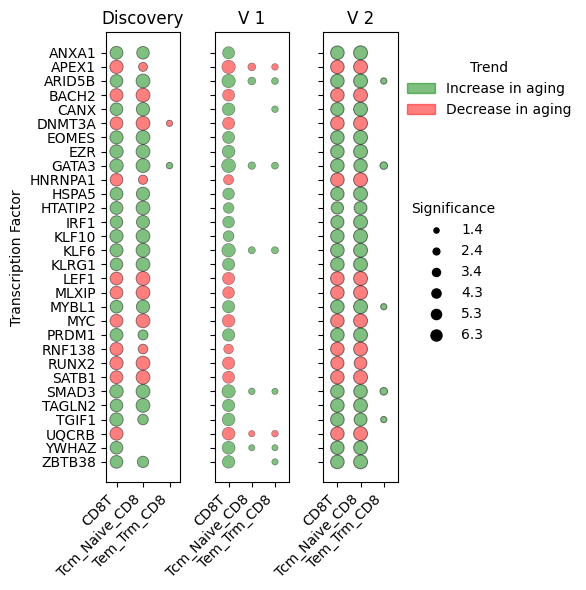

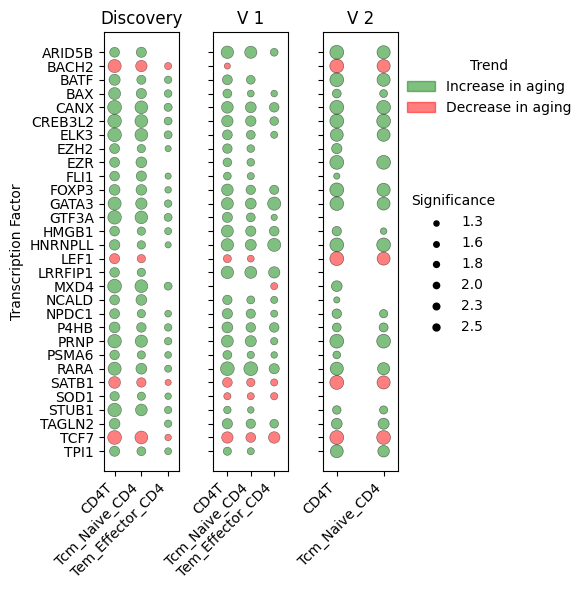

In [ ]:
n_top_tfs = 30
subtypes_toshow = {
        'CD8T': ['Tcm_Naive_CD8', 'Tem_Trm_CD8'],
        'CD4T': ['Tcm_Naive_CD4', 'Tem_Effector_CD4'],
}
for cell_type in ['CD8T', 'CD4T']:
        stats_main = retreive_stats(cell_type, types=['bulk'])
        tfs = stats_main.sort_values('meta_p_adj').head(n_top_tfs)['tf'].to_numpy()
        # - plot
        stats_main = stats_main[stats_main['cell_type']==cell_type]
        stats_main = add_minor_data(stats_main, cell_type)


        fig, axes = plt.subplots(1, 3, figsize=(6, 6), sharey=True)

        ax = axes[0]
        stats_main = stats_main[stats_main['tf'].isin(tfs)]
        stats_main.type = stats_main.type.apply(lambda name: {'bulk':f'{cell_type}'}.get(name,name))
        dotplot(stats_main, ax, x='type', y='tf', color_col='trend', size_col='-log10_pval', show_color_legend=False, show_size_legend=True,
                palette={key:palette_trend[key] for key in ['Increase in aging', 'Decrease in aging']}, sizes=(20, 100))    
        ax.margins(x=0.2, y=0.05)
        ax.set_title(f'Discovery')
        
        subtypes = subtypes_toshow[cell_type]+[cell_type]
        for i, dataset in enumerate(v_datasets):
                ax = axes[i+1]

                stats_main_v = wrapper_validation_stats(cell_types=[cell_type], type='bulk', tfs=tfs, dataset=dataset)
                stats_main_v = stats_main_v[stats_main_v['adj_p_value']<0.05]
                stats_main_v['neg_log10_adj_pval'] = -np.log10(stats_main_v['adj_p_value'])


                stats_minor_v = wrapper_validation_stats(cell_types=[cell_type], type='minor', tfs=tfs, dataset=dataset)
                stats_minor_v = stats_minor_v[stats_minor_v['adj_p_value']<0.05]
                stats_minor_v['neg_log10_adj_pval'] = -np.log10(stats_minor_v['adj_p_value'])

                stats_all = pd.concat([stats_main_v, stats_minor_v])
                stats_all = stats_all[stats_all['cell_type'].isin(subtypes)]

                if i == 0:
                        show_color_legend_l = False
                else:
                        show_color_legend_l = True
                dotplot(stats_all, ax, color_col='trend', 
                        size_col='neg_log10_adj_pval', 
                        palette=palette_trend_2, 
                        show_size_legend=True,
                        size_legend_title='Significance',
                        size_legend_loc=(1.1, 0.3),
                        sizes=(20, 100),
                        color_legend_loc=(1.05, 0.8),
                        show_color_legend = show_color_legend_l)
                ax.margins(x=0.3, y=0.05)
                ax.set_ylabel('')
                ax.set_title(f'V {i+1}')

        plt.tight_layout()
    

main
CD8T
Loading data...
Loading data...
cell_type
CD8T             30
Tcm_Naive_CD8    30
Tem_Temra_CD8    19
Tem_Trm_CD8       5
dtype: int64


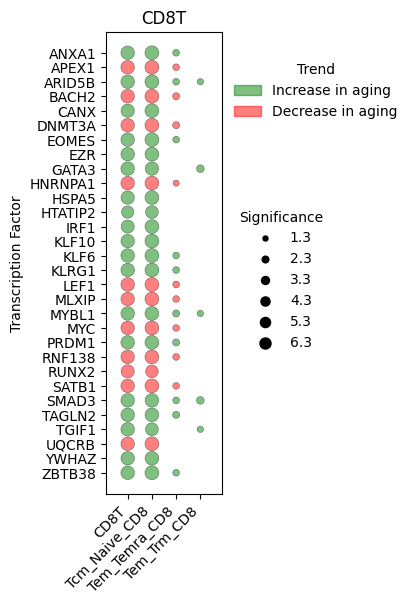

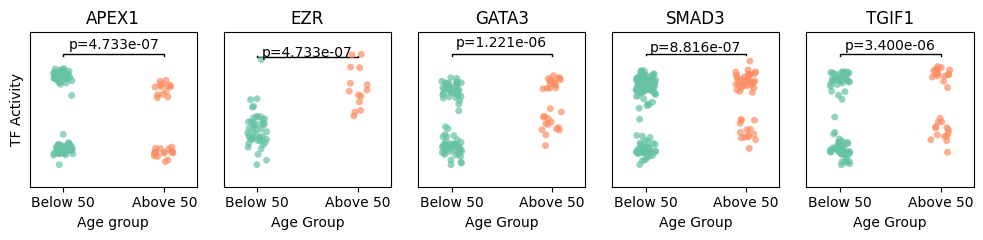

main
CD4T
Loading data...
Loading data...
cell_type
CD4T             27
Tcm_Naive_CD4    22
Treg              4
dtype: int64


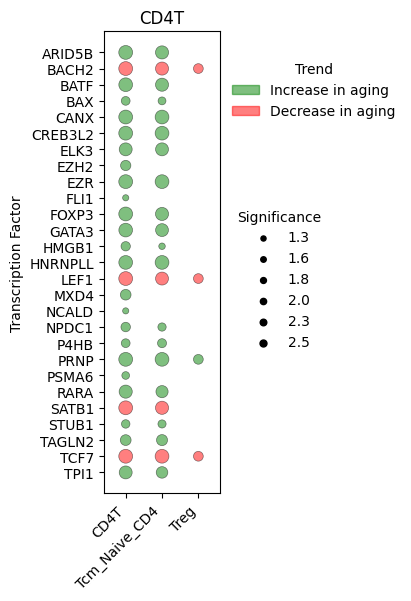

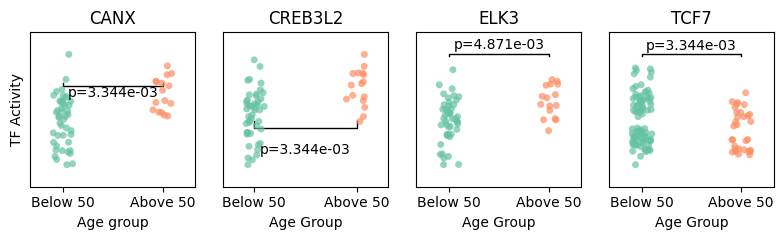

In [70]:
for cell_type in ['CD8T', 'CD4T']:
    stats_main = retreive_stats(cell_type, types=['bulk'])
    tfs = stats_main.sort_values('meta_p_adj').head(30)['tf'].to_numpy()

    stats_main_v = wrapper_validation_stats(cell_types=[cell_type], type='bulk', tfs=tfs, dataset=dataset)
    stats_main_v = stats_main_v[stats_main_v['adj_p_value']<0.05]
    stats_main_v['neg_log10_adj_pval'] = -np.log10(stats_main_v['adj_p_value'])


    stats_minor_v = wrapper_validation_stats(cell_types=[cell_type], type='minor', tfs=tfs, dataset=dataset)
    stats_minor_v = stats_minor_v[stats_minor_v['adj_p_value']<0.05]
    stats_minor_v['neg_log10_adj_pval'] = -np.log10(stats_minor_v['adj_p_value'])

    stats_all = pd.concat([stats_main_v, stats_minor_v])
    print(stats_all.groupby(['cell_type']).size())

    fig, ax = plt.subplots(1, 1, figsize=(1.5, 6))
    dotplot(stats_all, ax, color_col='trend', 
            size_col='neg_log10_adj_pval', 
            palette=palette_trend_2, 
            show_color_legend=True, 
            show_size_legend=True,
            size_legend_title='Significance',
            size_legend_loc=(1.1, 0.3),
            sizes=(20, 100),
            color_legend_loc=(1.05, 0.8))
    ax.margins(x=0.3, y=0.05)
    plt.title(cell_type)
    if stats_minor_v.shape[0]>0:
        plot_tf_act_validation(stats_minor_v[stats_minor_v['tf'].isin(tfs[:5])])


## Gender specific

main
F
M
CD8T
Loading data...
Loading data...
Loading data...
Loading data...
Loading data...
Loading data...


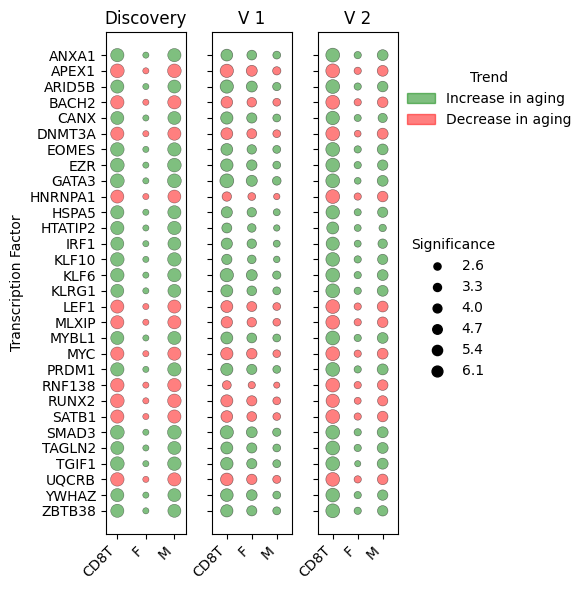

In [ ]:
n_top_tfs = 30

for cell_type in ['CD8T']:
        df_c = retreive_stats(cell_type, types=['bulk', 'F', 'M'], keep_sig=False)
        df_main = df_c[df_c['type']=='bulk']
        tfs = df_main.sort_values('meta_p_adj').head(n_top_tfs)['tf'].to_numpy()
        
        
        fig, axes = plt.subplots(1, 3, figsize=(6, 6), sharey=True)

        ax = axes[0]
        df_c = df_c[df_c['tf'].isin(tfs)]
        df_c['type'] = df_c['type'].apply(lambda name: {'bulk':f'{cell_type}'}.get(name,name))
        dotplot(df_c, ax, x='type', y='tf', color_col='trend', size_col='-log10_pval', 
                palette={key:palette_trend[key] for key in ['Increase in aging', 'Decrease in aging']}, sizes=(20, 100),
                show_color_legend=False)
        # plt.suptitle(cell_type, y=1.01, fontsize=14)
        ax.margins(x=0.2, y=0.05)
        ax.set_title(f'Discovery')
        
        for i, dataset in enumerate(v_datasets):
                ax = axes[i+1]
                
                stats_g_store = [] 
                for type in ['bulk', 'F', 'M']:
                        
                        stats_g = wrapper_validation_stats(cell_types=[cell_type], type=type, tfs=tfs, dataset=dataset)
                        stats_g = stats_g[stats_g['adj_p_value']<0.05]
                        stats_g['neg_log10_adj_pval'] = -np.log10(stats_g['adj_p_value'])
                        stats_g['type'] = type
                        stats_g_store.append(stats_g)
                
                stats_all = pd.concat(stats_g_store)

                if i == 0:
                        show_color_legend_l = False
                else:
                        show_color_legend_l = True
                stats_all['type'] = stats_all['type'].apply(lambda name: {'bulk':f'{cell_type}'}.get(name,name))
                dotplot(stats_all, ax,
                        x='type',
                        color_col='trend', 
                        size_col='neg_log10_adj_pval', 
                        palette=palette_trend_2, 
                        show_size_legend=True,
                        size_legend_title='Significance',
                        size_legend_loc=(1.1, 0.3),
                        sizes=(20, 100),
                        color_legend_loc=(1.05, 0.8),
                        show_color_legend = show_color_legend_l)
                ax.margins(x=0.3, y=0.05)
                ax.set_ylabel('')
                ax.set_title(f'V {i+1}')

        plt.tight_layout()
    


# Validation std

In [72]:
from ciim.src.tf_activity.script import wrapper_validation_stats
if False:
    stats_store = []
    for cell_type in ['CD8T', 'MONO']:
        stats_std_sig_t = stats_std_consistent[stats_std_consistent['cell_type'].isin([cell_type])]
        tfs = stats_std_sig_t.sort_values('meta_p_adj')['tf'].values
        stats = wrapper_validation_stats(cell_types=[cell_type], tfs=tfs, type='std', dataset=dataset)
        stats_store.append(stats)
    stats_std_v = pd.concat(stats_store)

    stats_std_v.to_csv(f'../output/tf_activation/stats_std_v_{dataset}.csv', index=False)
else:
    stats_std_v = pd.read_csv(f'../output/tf_activation/stats_std_v_{dataset}.csv')
stats_std_v.rename({'trend': 'trend'}, axis=1, inplace=True)
stats_std_v['neg_log10_adj_pval'] = -np.log10(stats_std_v['adj_p_value'])
stats_std_sig_v = stats_std_v[stats_std_v['adj_p_value']<0.05]

stats_std_sig_v.head()

FileNotFoundError: [Errno 2] No such file or directory: '../output/tf_activation/stats_std_v_data12.csv'

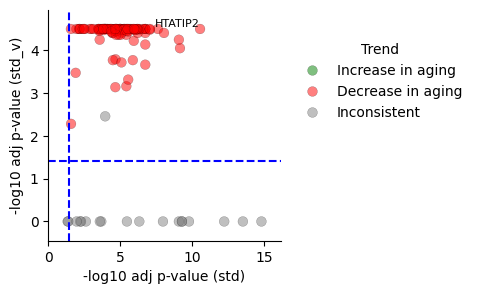

In [ ]:
for cell_type in ['CD8T']:
    s1 = stats_std_sig_v[stats_std_sig_v['cell_type']==cell_type]
    s2 = stats_std_sig[stats_std_sig['cell_type']==cell_type]

    s1['type'] = 'std_v'
    s2['type'] = 'std'

    ss = pd.concat([s1, s2])
    ss = ss[['tf', 'neg_log10_adj_pval', 'trend', 'type']].drop_duplicates()

    plot_joint_scatter(ss, vars=['std', 'std_v'], col='type')
    

In [71]:
if False:
    # - plot cases for MONO to show apparent but non signicant pattern
    
    stats_t = stats_std_v[stats_std_v['cell_type']=='MONO']
    tfs = stats_t.sort_values('adj_p_value').head(5)['tf'].values
    stats_t = stats_t[stats_t['tf'].isin(tfs)]
    plot_tf_act_validation(stats_t)

In [ ]:
# - combine data
from ciim.src.tf_activity.helper import process_rr
cell_type = 'CD8T'
# - std validation
std_v = stats_std_v[stats_std_v['cell_type']==cell_type]
std_v['type'] = 'std_v'

# - std discovery
std_d = stats_std_sig[stats_std_sig['cell_type']==cell_type]
std_d['type'] = 'std'

# - bulk tfs
bulk = stats_all_sig_consistent[stats_all_sig_consistent['cell_type']==cell_type]
bulk['type'] = 'bulk'


stats = pd.concat([std_v, std_d, bulk])

stats=stats[stats['trend']!='Inconsistent']
stats=stats[['tf', 'neg_log10_adj_pval', 'trend', 'type']].drop_duplicates()
stats.head()


,tf,neg_log10_adj_pval,linear_trend,type
0,ANXA1,4.477976,Decrease in aging,std_v
1,APEX1,4.491629,Decrease in aging,std_v
2,ARID5B,4.491629,Decrease in aging,std_v
3,ASCL2,4.465048,Decrease in aging,std_v
4,ATF6B,4.491629,Decrease in aging,std_v


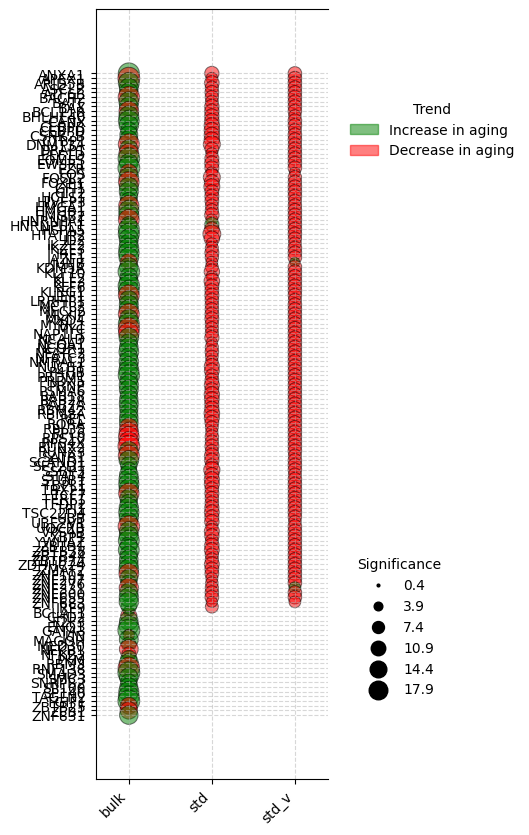

In [ ]:
tfs = tfs_sig_all[cell_type]
stats['type'] = stats['type'].astype(CategoricalDtype(categories=['bulk', 'std', 'std_v'], ordered=True))
stats_a = stats[stats['tf'].isin(tfs)]
fig, ax = plt.subplots(figsize=(3, 10))
dotplot(stats_a, ax, color_col='trend', size_col='neg_log10_adj_pval', 
            x='type', 
            y='tf', 
            palette=palette_trend_2, sizes=(50, 250),
            show_color_legend=True, 
            show_size_legend=True,
            size_legend_title='Significance',
            color_legend_title='Trend',
            size_legend_loc=(1.1, 0.1),
            color_legend_loc=(1.07, 0.8),
            y_label='',
            alpha=0.5)
ax.grid(True, linestyle="--", alpha=0.5)
ax.spines[['right']].set_visible(False)
ax.margins(x=.2, y=.1)

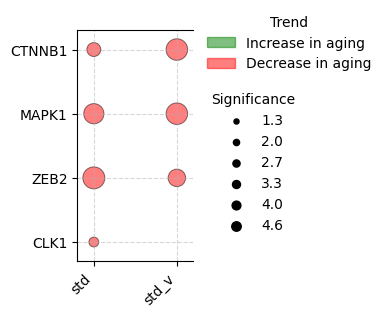

In [ ]:
# - those TFs unique to std (not sig in bulk)
unique_tfs_std = unique_tfs_std_dict[cell_type]
stats_u = stats[stats['tf'].isin(unique_tfs_std)]
fig, ax = plt.subplots(figsize=(1.5, 3))
dotplot(stats_u, ax, color_col='trend', size_col='neg_log10_adj_pval', 
            x='type', 
            y='tf', 
            palette=palette_trend_2, sizes=(50, 250),
            show_color_legend=True, 
            show_size_legend=True,
            size_legend_title='Significance',
            color_legend_title='Trend',
            size_legend_loc=(1.1, 0.1),
            color_legend_loc=(1.07, 0.8),
            y_label='',
            alpha=0.5)
ax.grid(True, linestyle="--", alpha=0.5)
ax.spines[['right']].set_visible(False)
ax.margins(x=.2, y=.1)